In [2]:
## Day 9
## Hour 1
## Block 1
import pandas as pd
df = pd.read_csv('House_price_train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
## Block 1
df.groupby('Neighborhood')['SalePrice'].mean()
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
## Block 2
## Multiindex - grouping within group
## Group with multiple columns
df.groupby(['Neighborhood','HouseStyle'])['SalePrice'].mean()

Neighborhood  HouseStyle
Blmngtn       1Story        194870.882353
Blueste       2Story        137500.000000
BrDale        2Story        104493.750000
BrkSide       1.5Fin        140924.000000
              1.5Unf        118750.000000
                                ...      
Timber        2Story        254112.555556
              SLvl          166875.000000
Veenker       1Story        243937.500000
              2Story        294000.000000
              SLvl          190500.000000
Name: SalePrice, Length: 96, dtype: float64

In [15]:
df.groupby(['Neighborhood','HouseStyle'])['SalePrice'].mean().loc['NAmes']

HouseStyle
1.5Fin    131053.333333
1.5Unf    120250.000000
1Story    141184.169811
2Story    172745.454545
SFoyer    140393.333333
SLvl      167535.714286
Name: SalePrice, dtype: float64

In [24]:
## Hour 2
## Block 1
## Basic Multiple Aggregation
df.groupby('Neighborhood')['SalePrice'].agg(['mean','max','min'])

## Diff aggregations for different columns
df.groupby('Neighborhood').agg({'SalePrice':['mean','max'],'GrLivArea':['mean','sum']})

## Named Aggregations
df.groupby('Neighborhood').agg(avg_price = ('SalePrice','mean'),
                               max_price=('SalePrice','max'),
                               avg_area = ('GrLivArea','mean'))

## Sort Results
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

df.groupby('Neighborhood').size()
df.groupby('Neighborhood').agg(
    avg_price=('SalePrice','mean'),
    count=('SalePrice','count')
)


,avg_price,count
Neighborhood,,
Blmngtn,194870.882353,17
Blueste,137500.000000,2
BrDale,104493.750000,16
BrkSide,124834.051724,58
ClearCr,212565.428571,28
CollgCr,197965.773333,150
Crawfor,210624.725490,51
Edwards,128219.700000,100
Gilbert,192854.506329,79


In [37]:
## Block 2
## Transform

df['Neighborhood_Avg_Price'] = df.groupby('Neighborhood')['SalePrice'].transform('mean')
df['price_diff'] = df['SalePrice'] - df.groupby('Neighborhood')['SalePrice'].transform('mean')
df['price_diff']
df['area_rank'] = df.groupby('Neighborhood')['GrLivArea'].transform('rank')
df['avg_area'] = df.groupby('Neighborhood')['GrLivArea'].transform('mean')
df.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Neighborhood_Avg_Price,price_diff,area_rank,avg_area
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,2,2008,WD,Normal,208500,197965.773333,10534.226667,102.0,1480.500000
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,5,2007,WD,Normal,181500,238772.727273,-57272.727273,3.0,1539.636364
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,9,2008,WD,Normal,223500,197965.773333,25534.226667,114.5,1480.500000
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,2,2006,WD,Abnorml,140000,210624.725490,-70624.725490,26.0,1791.607843
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,12,2008,WD,Normal,250000,335295.317073,-85295.317073,11.0,2508.853659
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,700,10,2009,WD,Normal,143000,156270.122449,-13270.122449,32.0,1294.204082
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,8,2007,WD,Normal,307000,225379.837209,81620.162791,59.0,1596.651163
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,350,11,2009,WD,Normal,200000,189050.068493,10949.931507,61.0,1727.780822
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,4,2008,WD,Abnorml,129900,128225.300885,1674.699115,86.5,1479.725664
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,1,2008,WD,Normal,118000,124834.051724,-6834.051724,24.0,1203.068966


In [46]:
## Hour 3
## Block 1
df1 = df[['Neighborhood','SalePrice']]
df2 = df.groupby('Neighborhood')['SalePrice'].mean().reset_index()
df2.rename(columns={'SalePrice':'AvgPrice'},inplace=True)
merged = pd.merge(df1,df2,on='Neighborhood',how='left')
print("left",merged.head(),merged.shape)
merged = pd.merge(df1,df2,on='Neighborhood',how='right')
print('right',merged.head(),merged.shape)
merged = pd.merge(df1,df2,on='Neighborhood',how='inner')
print('inner',merged.head(),merged.shape)
merged = pd.merge(df1, df2, on='Neighborhood', how='outer')
print('outer',merged.head(),merged.shape)
print(df1.shape)
print(df2.shape)

left   Neighborhood  SalePrice       AvgPrice
0      CollgCr     208500  197965.773333
1      Veenker     181500  238772.727273
2      CollgCr     223500  197965.773333
3      Crawfor     140000  210624.725490
4      NoRidge     250000  335295.317073 (1460, 3)
right   Neighborhood  SalePrice       AvgPrice
0      Blmngtn     167240  194870.882353
1      Blmngtn     192500  194870.882353
2      Blmngtn     192000  194870.882353
3      Blmngtn     172500  194870.882353
4      Blmngtn     178740  194870.882353 (1460, 3)
inner   Neighborhood  SalePrice       AvgPrice
0      CollgCr     208500  197965.773333
1      Veenker     181500  238772.727273
2      CollgCr     223500  197965.773333
3      Crawfor     140000  210624.725490
4      NoRidge     250000  335295.317073 (1460, 3)
outer   Neighborhood  SalePrice       AvgPrice
0      Blmngtn     167240  194870.882353
1      Blmngtn     192500  194870.882353
2      Blmngtn     192000  194870.882353
3      Blmngtn     172500  194870.882353
4   

In [ ]:
## Block 2
## Merge vs Join vs Concat
## Axis = 0 -- increases row, Axis =1 ----increases coloumns
## Join is used to attach using index


In [ ]:
## Hour 4
## Feature Transformation

In [52]:
## Block 3
## Binning
df['price_category'] = pd.cut(
    df['SalePrice'],
    bins=[0,150000,300000,1000000],
    labels=['Low','Medium','High']
)
## Area Binning
df['area_category'] = pd.cut(df['GrLivArea'],bins=3, labels=['small','medium','large'])

## Quantile Binning
df['price_quantile']=pd.qcut(df['SalePrice'],q=4,labels=['Q1','Q2','Q3','Q4'])

df['area_bin'] = pd.qcut(df['GrLivArea'], q=4)
df['area_bin'].value_counts()

area_bin
(1129.5, 1464.0]     366
(333.999, 1129.5]    365
(1776.75, 5642.0]    365
(1464.0, 1776.75]    364
Name: count, dtype: int64

In [57]:
## Hour 5 
## Mini Project
## feature Segmentation

df['price_segment'] = pd.qcut(df['SalePrice'],q=3,labels=['Low','Medium','High'])
df['area_segment'] = pd.qcut(df['GrLivArea'],q=3,labels=['Small','Medium','Large'])
df['quality_segment'] = pd.cut(df['OverallQual'],bins=[0,4,7,10],labels=['Low','Medium','Large'])


## Block 2
## Average price per segment
df.groupby('price_segment')['SalePrice'].mean()

## Area vs price
df.groupby(['area_segment','price_segment'])['SalePrice'].mean()

## Quality Vs Price
df.groupby('quality_segment')['SalePrice'].mean()

## Block 4
## Combine Segments
df.groupby(['area_segment','quality_segment'])['SalePrice'].mean()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3824\3773295977.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_segment')['SalePrice'].mean()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3824\3773295977.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['area_segment','price_segment'])['SalePrice'].mean()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3824\3773295977.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

area_segment  quality_segment
Small         Low                 97861.707547
              Medium             131771.198413
              Large              179633.333333
Medium        Low                119540.038462
              Medium             167295.577114
              Large              249602.741379
Large         Low                122277.777778
              Medium             202088.735484
              Large              326412.869048
Name: SalePrice, dtype: float64

In [58]:
df['price_segment'].value_counts()

price_segment
Medium    490
Low       487
High      483
Name: count, dtype: int64

In [61]:
df['premium_flag'] = (df['SalePrice'] > df['Neighborhood_Avg_Price']).astype(int)

df.to_csv("house_price_v4_features.csv", index=False)
df2= pd.read_csv("house_price_v4_features.csv")
df2.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,area_rank,avg_area,price_category,area_category,price_quantile,area_bin,price_segment,area_segment,quality_segment,premium_flag
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,102.0,1480.500000,Medium,small,Q3,"(1464.0, 1776.75]",High,Large,Medium,1
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,3.0,1539.636364,Medium,small,Q3,"(1129.5, 1464.0]",Medium,Medium,Medium,0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,114.5,1480.500000,Medium,small,Q4,"(1776.75, 5642.0]",High,Large,Medium,1
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,26.0,1791.607843,Low,small,Q2,"(1464.0, 1776.75]",Medium,Large,Medium,0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,11.0,2508.853659,Medium,medium,Q4,"(1776.75, 5642.0]",High,Large,Large,0


In [63]:
import pandas as pd

# Load cleaned dataset (v2)
df = pd.read_csv("house_price_cleaned_v2.csv")

# --- Feature Engineering ---

# Neighborhood average price
df['Neighborhood_Avg_Price'] = df.groupby('Neighborhood')['SalePrice'].transform('mean')

# Price difference from neighborhood average
df['price_diff'] = df['SalePrice'] - df['Neighborhood_Avg_Price']

# Area rank within neighborhood
df['area_rank'] = df.groupby('Neighborhood')['GrLivArea'].transform('rank')

# Average area per neighborhood
df['avg_area'] = df.groupby('Neighborhood')['GrLivArea'].transform('mean')

# Price per sqft
df['price_per_sqft'] = df['SalePrice'] / df['GrLivArea']

# Total square footage
df['TotalSF'] = df['TotalBsmtSF'] + df['GrLivArea']

# Overall score
df['overall_score'] = df['OverallQual'] * df['GrLivArea']

# Premium flag
df['premium_flag'] = (df['SalePrice'] > df['Neighborhood_Avg_Price']).astype(int)

# --- Segmentation ---

# Price segments
df['price_segment'] = pd.qcut(df['SalePrice'], q=3, labels=['Low','Medium','High'])

# Area segments
df['area_segment'] = pd.qcut(df['GrLivArea'], q=3, labels=['Small','Medium','Large'])

# Quality segments
df['quality_segment'] = pd.cut(df['OverallQual'], bins=[0,4,7,10], labels=['Low','Medium','High'])

# --- Save v4 dataset ---
df.to_csv("house_price_v4_features.csv", index=False)

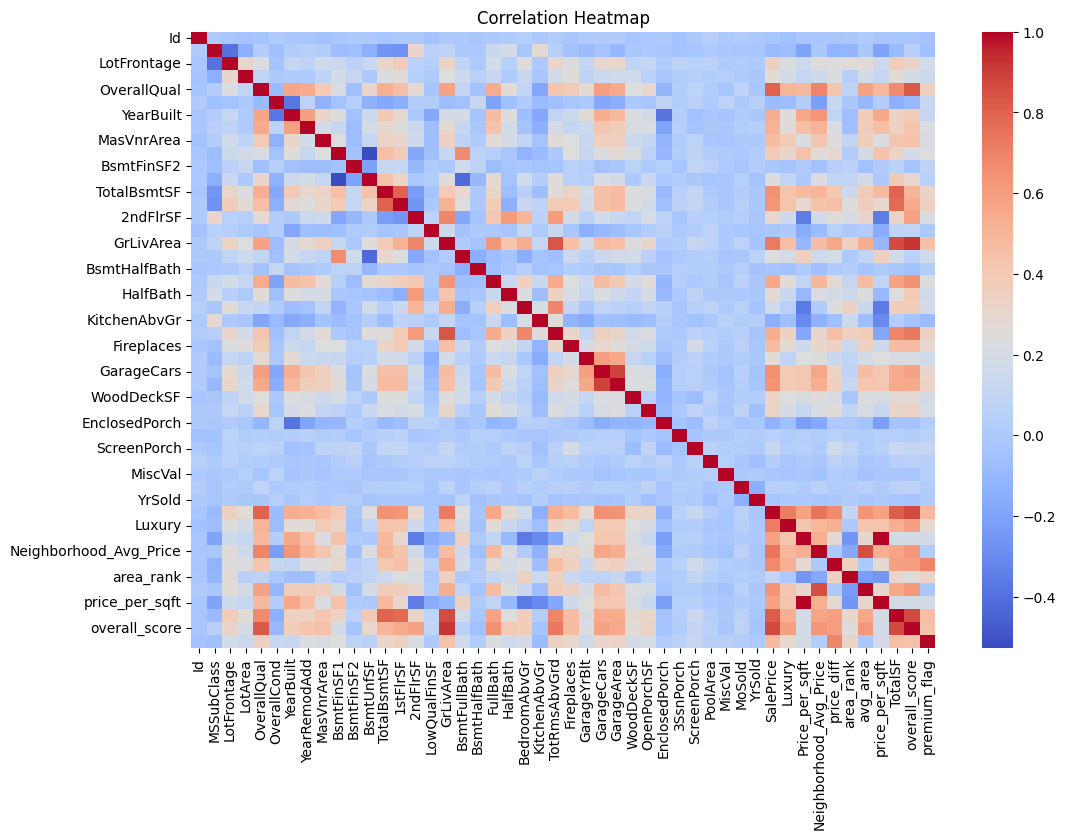

In [68]:
## Hour 6
## Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('house_price_v4_features.csv')
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [70]:
corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(10))

SalePrice                 1.000000
overall_score             0.864957
TotalSF                   0.821091
OverallQual               0.800858
Neighborhood_Avg_Price    0.744223
GrLivArea                 0.720516
Luxury                    0.715710
price_diff                0.667931
GarageCars                0.649256
TotalBsmtSF               0.646584
Name: SalePrice, dtype: float64


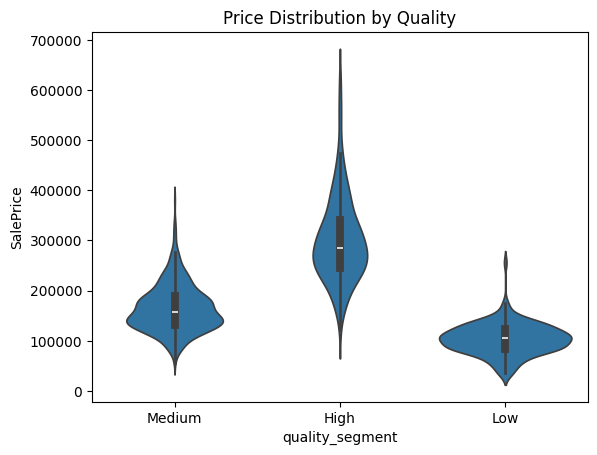

In [ ]:
## Violin Plot
sns.violinplot(x='quality_segment', y='SalePrice', data=df)
plt.title("Price Distribution by Quality")
plt.show()

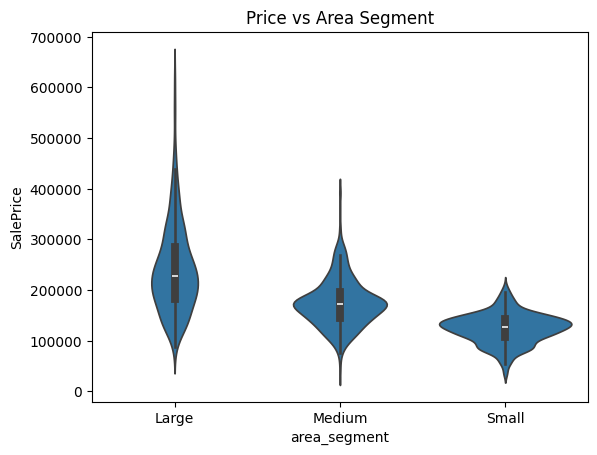

In [72]:
# Block 4 — Area vs Price
sns.violinplot(x='area_segment', y='SalePrice', data=df)
plt.title("Price vs Area Segment")
plt.show()

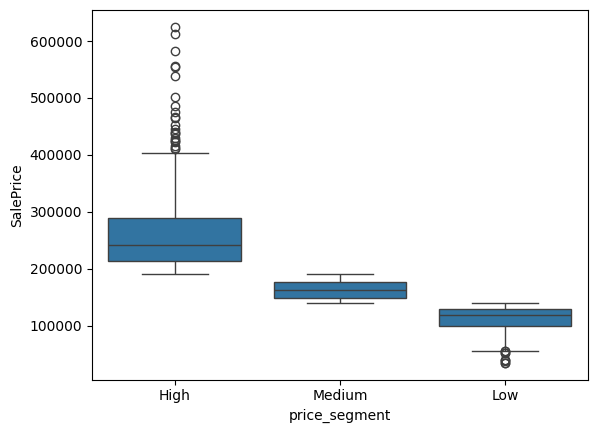

In [73]:
sns.boxplot(x='price_segment', y='SalePrice', data=df)
plt.show()

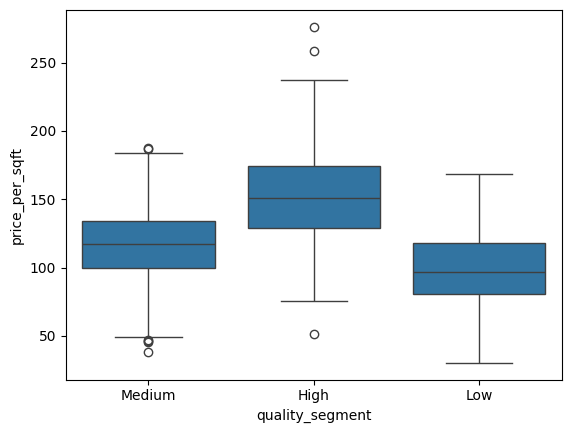

In [74]:
sns.boxplot(x='quality_segment', y='price_per_sqft', data=df)
plt.show()

In [76]:
## Hour 7
## Pallindrome
import re

s = "A man, a plan, a canal: Panama"
s = re.sub(r'[^a-zA-Z0-9]', '', s).lower()
print(s == s[::-1])

True


In [ ]:
## Block 2
## Length of last word
s="hello word"
# count=0
# for i in s[::-1]:
#     if i==' ':
#         break
#     else:
#         count+=1
# print(count)
# print(s[::-1])

# print(len(s.strip().split()[-1]))

## Block 3
## find first non-repeating character index
j=0
for i in s.strip():
    if i not in s[j+1:len(s)]:
        print(i)
        break
    j+=1

## Other Solutions
from collections import Counter
count = Counter(s)
for i in count:
    if count[i]==1:
        print(i)
        break

h
h


In [96]:
## Hour 8
df=pd.read_csv('house_price_v4_features.csv')
df.head()
df.isnull().sum().sum()
df.dtypes
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1456.0,7.299670e+02,421.722909,1.000000,364.750000,730.500000,1094.250000,1460.000000
MSSubClass,1456.0,5.688874e+01,42.358363,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1456.0,6.990694e+01,21.335081,21.000000,60.000000,70.000000,80.000000,313.000000
LotArea,1456.0,1.044878e+04,9860.763449,1300.000000,7538.750000,9468.500000,11588.000000,215245.000000
OverallQual,1456.0,6.088599e+00,1.369669,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1456.0,5.576236e+00,1.113966,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1456.0,1.971185e+03,30.201590,1872.000000,1954.000000,1972.000000,2000.000000,2010.000000
YearRemodAdd,1456.0,1.984819e+03,20.652143,1950.000000,1966.750000,1993.500000,2004.000000,2010.000000
MasVnrArea,1456.0,1.015268e+02,177.011773,0.000000,0.000000,0.000000,163.250000,1600.000000
BsmtFinSF1,1456.0,4.369911e+02,430.255052,0.000000,0.000000,381.000000,706.500000,2188.000000


In [100]:
cols = [
    'price_per_sqft',
    'Neighborhood_Avg_Price',
    'price_diff',
    'area_rank',
    'premium_flag'
]

df[cols].head()

df['price_segment'].value_counts()
df['area_segment'].value_counts()
# df['quality_segment'].value_counts()

df.to_csv('house_price_v4_final.csv')